In [1]:
import pandas as pd
import sqlite3
import plotly.graph_objects as go
import numpy as np

## Connect and get data

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

commits = pd.io.sql.read_sql(
    """
    SELECT uid, timestamp
    FROM checker
    WHERE uid LIKE 'user_%'
    AND status = 'ready'
    AND labname = 'project1'
    """,
    conn,
    parse_dates=['timestamp']
)

conn.close()
commits.head()

,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:45.549397
2,user_4,2020-04-17 05:34:24.422370
3,user_4,2020-04-17 05:43:27.773992
4,user_4,2020-04-17 05:46:32.275104


## Prepare cumulative commits

In [3]:
commits = commits.sort_values('timestamp').reset_index(drop=True)
commits['cum_commits'] = commits.groupby('uid').cumcount() + 1

# Create a common time index
all_times = sorted(commits['timestamp'].unique())
users = commits['uid'].unique()

# Build full grid: for each user, forward-fill cumulative commits at each timestamp
user_data = {}
for user in users:
    udf = commits[commits['uid'] == user][['timestamp', 'cum_commits']].set_index('timestamp')
    udf = udf.reindex(all_times).ffill().fillna(0)
    user_data[user] = udf['cum_commits'].values

print('Users:', len(users))
print('Timepoints:', len(all_times))

Users: 27
Timepoints: 951


## Create animated Plotly chart

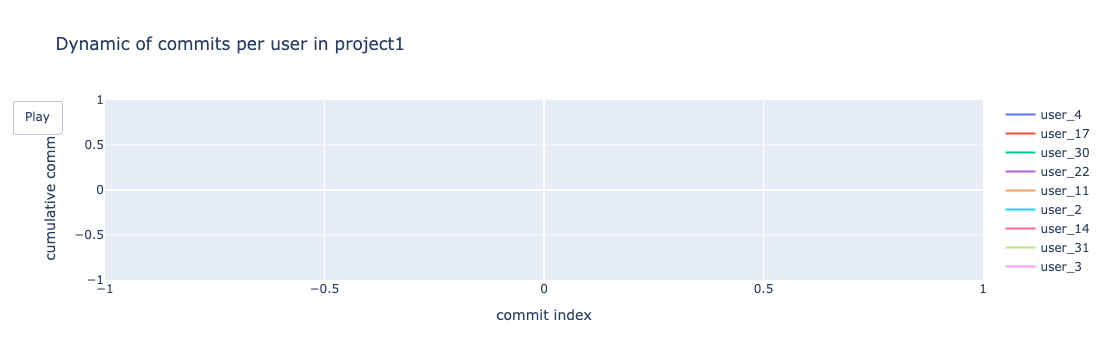

In [4]:
# Build frames for animation
step = max(1, len(all_times) // 20)  # 20 animation frames
frame_indices = list(range(0, len(all_times), step)) + [len(all_times) - 1]

frames = []
for fi in frame_indices:
    frame_data = []
    for user in users:
        frame_data.append(
            go.Scatter(
                x=list(range(fi + 1)),
                y=user_data[user][:fi + 1],
                mode='lines',
                name=user
            )
        )
    frames.append(go.Frame(data=frame_data, name=str(fi)))

# Initial traces
initial_traces = []
for user in users:
    initial_traces.append(
        go.Scatter(
            x=[0],
            y=[0],
            mode='lines',
            name=user
        )
    )

fig = go.Figure(
    data=initial_traces,
    frames=frames,
    layout=go.Layout(
        title='Dynamic of commits per user in project1',
        xaxis_title='commit index',
        yaxis_title='cumulative commits',
        updatemenus=[
            dict(
                type='buttons',
                showactive=False,
                buttons=[
                    dict(
                        label='Play',
                        method='animate',
                        args=[None, {'frame': {'duration': 300, 'redraw': True}, 'fromcurrent': True}]
                    )
                ]
            )
        ]
    )
)

fig.show()